# 멀티레이블 텍스트 분류

멀티레이블 분류는 문서 하나에 여러 정답 레이블을 동시에 부여하는 작업이다. 영화 한 편이 `판타지`이면서 `모험`일 수 있고, 뉴스 한 건이 `경제`와 `정치`를 함께 다룰 수 있다.

단일 레이블 분류처럼 하나만 고르면 나머지 올바른 레이블을 잃게 된다. 따라서 클래스마다 독립적인 이진 분류기를 학습하고, 각 확률이 임계값을 넘는지를 따로 판단한다.

이번 교안은 36개의 작은 영화 설명으로 TF-IDF와 One-vs-Rest Logistic Regression을 실제 학습한다. `0.3`, `0.5`, `0.7` 임계값에 따라 예측 레이블 수와 micro·macro F1, Hamming loss가 어떻게 달라지는지 확인한다.

## 01. 멀티레이블 분류의 정답과 확률

멀티레이블 정답은 클래스 ID 하나가 아니라 클래스 수만큼의 0과 1을 가진 multi-hot 벡터이다. 예를 들어 클래스 순서가 `[판타지, 모험, 로맨스]`라면 `판타지+모험`의 정답은 `[1, 1, 0]`이다.

One-vs-Rest 방식은 레이블마다 “이 레이블인가?”를 판단하는 이진 분류기 하나를 만든다. 각 분류기는 다른 레이블과 독립된 확률을 반환하므로 여러 확률이 동시에 임계값을 넘을 수 있다.

- **multi-hot 벡터**: 해당 레이블 위치는 1, 나머지는 0인 다중 정답 표현
- **sigmoid 확률**: 레이블마다 독립적으로 계산한 0~1 값
- **임계값(Threshold)**: 확률을 최종 0 또는 1로 바꾸는 기준
- **micro F1**: 모든 레이블의 예측을 합쳐 전체 정답 성능을 계산한 값
- **macro F1**: 레이블별 F1을 같은 비중으로 평균한 값
- **Hamming loss**: 전체 레이블 위치 중 잘못 켜거나 끈 비율이며 작을수록 좋다.


## 02. 단일 레이블과 멀티레이블의 출력 차이

단일 레이블 분류는 후보 중 하나만 정답이므로 소프트맥스로 클래스 확률의 합을 1로 만든다. 멀티레이블 분류는 각 레이블이 서로 독립적으로 참 또는 거짓이 될 수 있으므로 레이블마다 sigmoid 확률을 계산하고 임계값보다 큰 항목을 모두 선택한다.

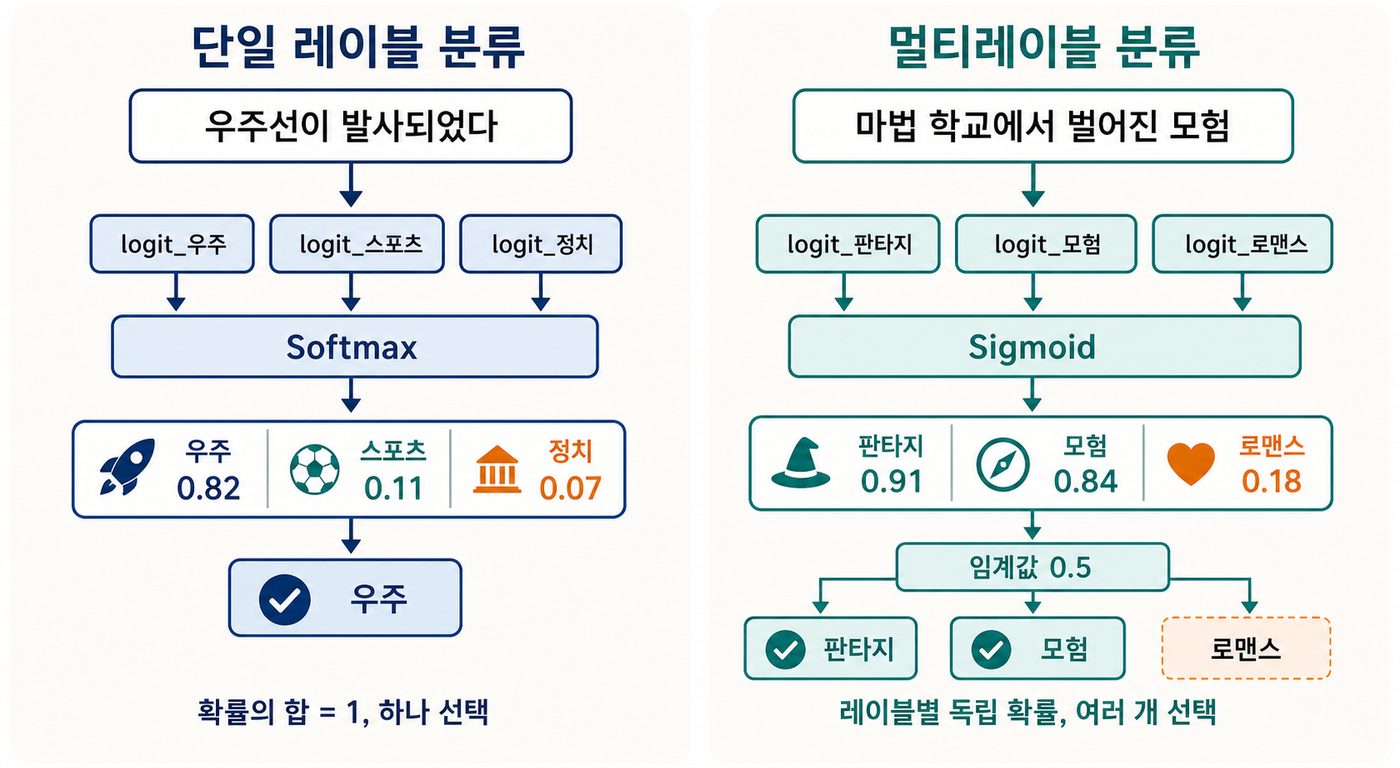


### 여러 장르를 가진 작은 영화 설명 데이터

각 조합에 여섯 문장을 두어 단일 장르와 두 장르 조합을 모두 포함한다. 장르를 직접 연상시키는 단어를 반복해 작은 데이터에서도 학습 과정을 볼 수 있게 만든 수업용 데이터이며, 실제 영화 분류 성능을 대표하지 않는다.


In [2]:
from importlib.metadata import version

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, hamming_loss
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer

examples_by_labels = {
    ("판타지",): [
        "마법 주문으로 저주를 풀었다",
        "마법 용이 왕국을 지켰다",
        "마법 요정이 신비한 숲을 되살렸다",
        "마법 지팡이가 숨은 힘을 드러냈다",
        "판타지 왕자가 예언의 검을 찾았다",
        "마법 마녀가 달빛 아래 주문을 외웠다",
    ],
    ("모험",): [
        "모험 탐험대가 정글 유적을 발견했다",
        "모험 해적들이 보물섬을 찾아 항해했다",
        "모험 등산가가 폭풍 속 정상에 올랐다",
        "모험 구조대가 동굴 실종자를 찾았다",
        "모험 우주비행사가 미지 행성에 착륙했다",
        "모험 기차 추격전 끝에 범인을 잡았다",
    ],
    ("로맨스",): [
        "로맨스 두 사람은 서점에서 만나 사랑에 빠졌다",
        "로맨스 오랜 친구가 연인이 되어 결혼했다",
        "로맨스 첫사랑을 다시 만나 마음을 고백했다",
        "로맨스 연인은 바닷가에서 마음을 확인했다",
        "로맨스 편지로 이어진 사랑이 이루어졌다",
        "로맨스 두 주인공이 축제에서 사랑을 시작했다",
    ],
    ("판타지", "모험"): [
        "마법 학교 학생들이 금지된 숲을 모험했다",
        "마법 기사가 용의 성으로 모험을 떠났다",
        "마법 요정과 전사가 보물을 찾아 모험했다",
        "마법사가 모험대와 어둠의 탑에 올랐다",
        "마법 지도는 판타지 왕국의 모험을 이끌었다",
        "마법 용사들이 주문을 배우며 던전을 모험했다",
    ],
    ("모험", "로맨스"): [
        "로맨스 두 연인이 함께 세계 모험을 떠났다",
        "모험가와 기자는 모험 속에서 사랑에 빠졌다",
        "로맨스 연인은 보물을 찾는 모험 항해를 했다",
        "모험 탈출 중 두 사람의 로맨스가 시작됐다",
        "모험 원정대의 두 대원이 사랑을 고백했다",
        "모험 추격전을 겪은 주인공이 연인이 되었다",
    ],
    ("판타지", "로맨스"): [
        "마법사와 공주는 판타지 사랑에 빠졌다",
        "마법 요정과 기사의 로맨스가 왕국을 바꾸었다",
        "마법 마녀는 사랑을 지키기 위해 주문했다",
        "마법 저주받은 왕자와 소녀의 사랑이 시작됐다",
        "마법 학교에서 두 학생의 로맨스가 시작됐다",
        "판타지 왕국에서 로맨스 사랑이 피어났다",
    ],
}

# 레이블 조합별 문장을 (문장, 레이블 목록) 행으로 펼친다.
rows = [
    (text, list(labels))
    for labels, grouped_texts in examples_by_labels.items()
    for text in grouped_texts
]
texts = [text for text, _ in rows]
label_lists = [labels for _, labels in rows]

print("전체 문장 수:", len(texts))
print("레이블 조합 수:", len(examples_by_labels))
print("첫 문장과 정답:", texts[0], "→", label_lists[0])



전체 문장 수: 36
레이블 조합 수: 6
첫 문장과 정답: 마법 주문으로 저주를 풀었다 → ['판타지']


### 레이블 목록을 multi-hot 정답으로 변환하고 데이터 분리

`MultiLabelBinarizer`는 문자열 레이블 목록을 클래스 수만큼의 0과 1로 바꾼다. 클래스 순서를 고정해야 각 열의 의미가 실행마다 바뀌지 않는다.

레이블 조합을 기준으로 분할하면 학습과 테스트에 여섯 조합이 모두 포함된다. TF-IDF는 아직 만들지 않으며, 다음 셀에서 학습 문장에만 fit한다.


In [4]:
LABEL_ORDER = ["판타지", "모험", "로맨스"]

# (판타지, 로맨스) -> 판타지+로맨스
label_combinations = ["+".join(labels) for labels in label_lists]

all_indices = np.arange(len(texts)) # 0~35

# 레이블 조합 비율을 유지하도록 문장 인덱스를 층화 분할한다.
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=1 / 3,
    random_state=42,
    stratify=label_combinations,
)

mlb = MultiLabelBinarizer(classes=LABEL_ORDER) # MultiLabelBinarizer = 여러 레이블에 대한 이진 분류기

# 학습 분할의 레이블로 multi-hot 열 순서를 확정한다.
mlb.fit([label_lists[index] for index in train_indices])
# 레이블 목록을 (문장 수, 3개 레이블) multi-hot 행렬로 바꾼다.
Y = mlb.transform(label_lists)

print(Y)
print("레이블 열 순서:", mlb.classes_.tolist())
print("전체 정답 shape:", Y.shape)
print("판타지+모험 예:", ["판타지", "모험"], "→", Y[18].tolist())
print("분할 크기:", f"train={len(train_indices)}, test={len(test_indices)}")



[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [1 1 0]
 [1 1 0]
 [1 1 0]
 [1 1 0]
 [1 1 0]
 [1 1 0]
 [0 1 1]
 [0 1 1]
 [0 1 1]
 [0 1 1]
 [0 1 1]
 [0 1 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]]
레이블 열 순서: ['판타지', '모험', '로맨스']
전체 정답 shape: (36, 3)
판타지+모험 예: ['판타지', '모험'] → [1, 1, 0]
분할 크기: train=24, test=12


### TF-IDF와 One-vs-Rest Logistic Regression 학습

TF-IDF는 학습 문장에만 `fit_transform()`하고 테스트 문장에는 `transform()`만 적용한다. `OneVsRestClassifier`는 장르 세 개에 대해 Logistic Regression을 하나씩 학습한다.

각 이진 분류기의 출력은 해당 장르가 포함될 확률이므로 최종 확률 행렬 shape는 `(테스트 문장 수, 3)`이다.

다음 빈 코드셀에서 TF-IDF 변환과 One-vs-Rest 학습을 완성해야 뒤의 임계값 평가를 실행할 수 있다.

In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)

train_texts = [texts[index] for index in train_indices]
test_texts =  [texts[index] for index in test_indices]

# train 문장 24개에서 어휘/IDF를 학습하고 (24, 193) 형태의 희소 행렬 반환
# 193은 n-gram(1,2)로 인해 feature가 많이 생성된 결과.
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

# X와 같은 인덱스의 label 얻어오기
y_train = Y[train_indices]
y_test =Y[test_indices]


# 예측 결과마다 독립적인 로지스틱 분류 모델을 학습한다.
# 학습되는 label의 크기만큼 로지스틱이 복제되어 독립적으로 동작
model = OneVsRestClassifier(
    LogisticRegression(
        C=4.0, # 규제 강도는 역수이므로 1보다 규제가 약한 상태임(숫자가 클수록 규제가 약함)
        max_iter=1000, # 가중치 최적화를 위해 최대 1000번 반복 계산
        random_state=42,
    )
)

model.fit(X_train, y_train) # 학습

# 평가 데이터를 이용해서 각 label별 양성 확률 반환
test_probabilities = model.predict_proba(X_test)

print("학습 TF-IDF shape:", X_train.shape)
print("테스트 확률 shape:", test_probabilities.shape)
print("첫 테스트 문장의 확률 :", test_probabilities[0])
print("첫 테스트 문장의 확률 합:", round(float(test_probabilities[0].sum()), 3))


학습 TF-IDF shape: (24, 193)
테스트 확률 shape: (12, 3)
첫 테스트 문장의 확률 : [0.24329952 0.59655374 0.59349836]
첫 테스트 문장의 확률 합: 1.433


### 임계값에 따른 micro·macro F1과 Hamming loss

확률을 최종 레이블로 바꾸려면 임계값이 필요하다. 낮은 임계값은 레이블을 많이 선택해 정답 누락을 줄이지만 잘못된 레이블도 늘릴 수 있고, 높은 임계값은 확실한 레이블만 남겨 정답을 놓칠 수 있다.

먼저 문장 내용을 보지 않고 학습 레이블의 출현 비율만 반복하는 기준선을 계산한 뒤, 학습 모델의 세 임계값 결과와 비교한다. 실제 프로젝트에서는 테스트가 아니라 별도의 validation 데이터에서 임계값을 선택해야 한다.


In [6]:
# axis=0 평균으로 학습 데이터의 레이블별 등장 비율을 구한다.
label_prevalence = y_train.mean(axis=0)
# 0.5 이상인 레이블을 모든 테스트 행에 반복해 기준선을 만든다.
baseline_row = (label_prevalence >= 0.5).astype(int)
baseline_predictions = np.tile(baseline_row, (len(y_test), 1))
# micro는 전체 결정을 모으고 macro는 레이블별 F1을 평균한다.
baseline_micro_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="micro",
    zero_division=0,
)
baseline_macro_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro",
    zero_division=0,
)
baseline_hamming = hamming_loss(y_test, baseline_predictions)
print(
    "레이블 비율 기준선 | "
    f"micro F1={baseline_micro_f1:.3f} | "
    f"macro F1={baseline_macro_f1:.3f} | "
    f"Hamming loss={baseline_hamming:.3f}"
)
print()

evaluation_threshold = 0.5
diagnostic_thresholds = [0.3, evaluation_threshold, 0.7]

threshold_results = {}

for threshold in diagnostic_thresholds:
    # 각 확률을 임계값과 비교해 독립적인 0/1 예측으로 바꾼다.
    predictions = (test_probabilities >= threshold).astype(int)

    micro_f1 = f1_score(
        y_test,
        predictions,
        average="micro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )
    error_rate = hamming_loss(y_test, predictions)
    # axis=1 합으로 문장마다 선택된 레이블 수를 계산한다.
    average_label_count = predictions.sum(axis=1).mean()
    threshold_results[threshold] = predictions

    print(
        f"threshold={threshold:.1f} | "
        f"micro F1={micro_f1:.3f} | "
        f"macro F1={macro_f1:.3f} | "
        f"Hamming loss={error_rate:.3f} | "
        f"문장당 예측 레이블={average_label_count:.2f}"
    )



레이블 비율 기준선 | micro F1=0.667 | macro F1=0.667 | Hamming loss=0.500

threshold=0.3 | micro F1=0.706 | macro F1=0.711 | Hamming loss=0.417 | 문장당 예측 레이블=2.75
threshold=0.5 | micro F1=0.833 | macro F1=0.844 | Hamming loss=0.167 | 문장당 예측 레이블=1.50
threshold=0.7 | micro F1=0.435 | macro F1=0.389 | Hamming loss=0.361 | 문장당 예측 레이블=0.42


### 문장별 확률과 오예측 읽기

전체 지표만 보면 어떤 장르를 왜 놓쳤는지 알 수 없다. 임계값 `0.5`의 예측을 실제 장르와 나란히 읽고, 정답과 다른 행에서는 어떤 확률이 경계 근처에 있었는지 확인한다.


In [7]:
chosen_threshold = evaluation_threshold
chosen_predictions = threshold_results[chosen_threshold]
# multi-hot 행을 사람이 읽는 레이블 튜플로 되돌린다.
decoded_answers = mlb.inverse_transform(y_test)
decoded_predictions = mlb.inverse_transform(chosen_predictions)

wrong_count = 0
# 테스트 행 위치와 원본 문장 인덱스를 함께 순회한다.
for row_index, source_index in enumerate(test_indices):
    # 확률 열을 MultiLabelBinarizer의 레이블 순서와 연결한다.
    probability_by_label = {
        label: round(float(score), 4)
        for label, score in zip(mlb.classes_, test_probabilities[row_index])
    }
    answer = decoded_answers[row_index]
    prediction = decoded_predictions[row_index]

    print(f"\n문장: {texts[source_index]}")
    print("확률:", probability_by_label)
    print("정답:", answer, "/ 예측:", prediction)

    if answer != prediction:
        wrong_count += 1

print("\n오예측 문장 수:", wrong_count, "/", len(test_indices))




문장: 모험 추격전을 겪은 주인공이 연인이 되었다
확률: {'판타지': 0.2433, '모험': 0.5966, '로맨스': 0.5935}
정답: ('모험', '로맨스') / 예측: ('모험', '로맨스')

문장: 마법 저주받은 왕자와 소녀의 사랑이 시작됐다
확률: {'판타지': 0.7052, '모험': 0.3806, '로맨스': 0.5597}
정답: ('판타지', '로맨스') / 예측: ('판타지', '로맨스')

문장: 마법 기사가 용의 성으로 모험을 떠났다
확률: {'판타지': 0.4971, '모험': 0.6023, '로맨스': 0.5439}
정답: ('판타지', '모험') / 예측: ('모험', '로맨스')

문장: 마법 지도는 판타지 왕국의 모험을 이끌었다
확률: {'판타지': 0.6983, '모험': 0.4093, '로맨스': 0.543}
정답: ('판타지', '모험') / 예측: ('판타지', '로맨스')

문장: 로맨스 편지로 이어진 사랑이 이루어졌다
확률: {'판타지': 0.4806, '모험': 0.329, '로맨스': 0.6975}
정답: ('로맨스',) / 예측: ('로맨스',)

문장: 로맨스 연인은 보물을 찾는 모험 항해를 했다
확률: {'판타지': 0.3136, '모험': 0.6255, '로맨스': 0.545}
정답: ('모험', '로맨스') / 예측: ('모험', '로맨스')

문장: 모험 기차 추격전 끝에 범인을 잡았다
확률: {'판타지': 0.1959, '모험': 0.8108, '로맨스': 0.4284}
정답: ('모험',) / 예측: ('모험',)

문장: 마법 요정과 기사의 로맨스가 왕국을 바꾸었다
확률: {'판타지': 0.7133, '모험': 0.4849, '로맨스': 0.3824}
정답: ('판타지', '로맨스') / 예측: ('판타지',)

문장: 마법 요정이 신비한 숲을 되살렸다
확률: {'판타지': 0.7338, '모험': 0.4955, '로맨스': 0.3271}
정답: ('판타지',) / 예측: ('판타지',)



## 정리와 한계

멀티레이블 분류의 핵심 흐름은 `문장 → TF-IDF → 레이블별 독립 확률 → 임계값 → 여러 예측 레이블`이다. 모델을 학습하는 것만으로 최종 결과가 정해지지 않으며, 실제 용도에 맞는 임계값을 validation 데이터에서 선택해야 한다.

이번 데이터는 학습 흐름을 빠르게 확인하도록 장르 단서를 명확히 반복한 작은 예제이다. 높은 점수가 나오더라도 실제 서비스의 일반화 성능으로 해석하지 않는다. 실제 문제에서는 충분한 데이터, 레이블 불균형 처리, 레이블별 임계값과 독립된 test 평가가 필요하다.
